# Mancala Project Final Report


In [1]:
import random
random.seed(109)

In [2]:
class Mancala:
    def __init__(self, pits_per_player=6, stones_per_pit = 4):
        """
        The constructor for the Mancala class defines several instance variables:

        pits_per_player: This variable stores the number of pits each player has.
        stones_per_pit: It represents the number of stones each pit contains at the start of any game.
        board: This data structure is responsible for managing the Mancala board.
        current_player: This variable takes the value 1 or 2, as it's a two-player game, indicating which player's turn it is.
        moves: This is a list used to store the moves made by each player. It's structured in the format (current_player, chosen_pit).
        p1_pits_index: A list containing two elements representing the start and end indices of player 1's pits in the board data structure.
        p2_pits_index: Similar to p1_pits_index, it contains the start and end indices for player 2's pits on the board.
        p1_mancala_index and p2_mancala_index: These variables hold the indices of the Mancala pits on the board for players 1 and 2, respectively.
        """
        self.pits_per_player = pits_per_player
        self.board = [stones_per_pit] * ((pits_per_player+1) * 2)  # Initialize each pit with stones_per_pit number of stones 
        self.players = 2
        self.current_player = 1
        self.moves = []
        self.p1_pits_index = [0, self.pits_per_player-1]
        self.p1_mancala_index = self.pits_per_player
        self.p2_pits_index = [self.pits_per_player+1, len(self.board)-1-1]
        self.p2_mancala_index = len(self.board)-1
        
        # Zeroing the Mancala for both players
        self.board[self.p1_mancala_index] = 0
        self.board[self.p2_mancala_index] = 0

    def display_board(self):
        """
        Displays the board in a user-friendly format
        """
        player_1_pits = self.board[self.p1_pits_index[0]: self.p1_pits_index[1]+1]
        player_1_mancala = self.board[self.p1_mancala_index]
        player_2_pits = self.board[self.p2_pits_index[0]: self.p2_pits_index[1]+1]
        player_2_mancala = self.board[self.p2_mancala_index]

        print('P1               P2')
        print('     ____{}____     '.format(player_2_mancala))
        for i in range(self.pits_per_player):
            if i == self.pits_per_player - 1:
                print('{} -> |_{}_|_{}_| <- {}'.format(i+1, player_1_pits[i], 
                        player_2_pits[-(i+1)], self.pits_per_player - i))
            else:    
                print('{} -> | {} | {} | <- {}'.format(i+1, player_1_pits[i], 
                        player_2_pits[-(i+1)], self.pits_per_player - i))
            
        print('         {}         '.format(player_1_mancala))
        turn = 'P1' if self.current_player == 1 else 'P2'
        print('Turn: ' + turn)
        
    def valid_move(self, pit):
        """
        Function to check if the pit chosen by the current_player is a valid move.
        """
        
        # write your code here
        if pit > self.pits_per_player or pit < 1:
            return False
        if self.current_player == 1:
            board_index = pit - 1
        else:
            board_index = self.p2_pits_index[0] + pit-1
        
        return self.board[board_index] > 0
        
    def random_move_generator(self):
        """
        Function to generate random valid moves with non-empty pits for the random player
        """
        
        # write your code here
        valid_moves = []
        for pit in range(1, self.pits_per_player + 1):
            if self.current_player == 1:
                board_index = pit - 1
            else:
                board_index = self.p2_pits_index[0] + pit-1
            if self.board[board_index] > 0:
                valid_moves.append(pit)
        return random.choice(valid_moves)
    
    def play(self, pit):
        """
        This function simulates a single move made by a specific player using their selected pit. It primarily performs three tasks:
        1. It checks if the chosen pit is a valid move for the current player. If not, it prints "INVALID MOVE" and takes no action.
        2. It verifies if the game board has already reached a winning state. If so, it prints "GAME OVER" and takes no further action.
        3. After passing the above two checks, it proceeds to distribute the stones according to the specified Mancala rules.

        Finally, the function then switches the current player, allowing the other player to take their turn.
        """
        
        # write your code here

        game_over, winner = self.winning_eval()
        if game_over:
            print("GAME OVER")
            return self.board
        
        # Checking for valid move
        if not self.valid_move(pit):
            print("INVALID MOVE")
            return self.board
        
        self.moves.append((self.current_player, pit))

        # Convering the pit number to board index and distribute
        if self.current_player == 1:
            board_index = pit - 1
        else:
            board_index = self.p2_pits_index[0] + pit-1
        
        opponent_mancala = self.p2_mancala_index if self.current_player == 1 else self.p1_mancala_index
        stones = self.board[board_index]
        self.board[board_index] = 0
        position = board_index
        while stones > 0:
            position = (position + 1) % len(self.board)
            if position == opponent_mancala:
                continue
            self.board[position] += 1
            stones -= 1
        last_position = position

        # Taking opponent's stones if last stone lands in empty pit on current player's side
        mancala = self.p1_mancala_index if self.current_player == 1 else self.p2_mancala_index
        pits_start = self.p1_pits_index[0] if self.current_player == 1 else self.p2_pits_index[0]
        pits_end = self.p1_pits_index[1] if self.current_player == 1 else self.p2_pits_index[1]

        if (pits_start <= last_position <= pits_end) and self.board[last_position] == 1 and self.board[2 * self.pits_per_player - last_position] > 0:
            opposite_index = 2 * self.pits_per_player - last_position
            self.board[mancala] += self.board[last_position] + self.board[opposite_index]
            self.board[last_position] = 0
            self.board[opposite_index] = 0

        # Finalizing eval
        self.winning_eval()

        # Switching player
        self.current_player = 2 if self.current_player == 1 else 1

        return self.board
    
    def winning_eval(self):
        """
        Function to verify if the game board has reached the winning state.
        Hint: If either of the players' pits are all empty, then it is considered a winning state.
        """
        
        
        # write your code here
        p1_pits_sum = sum(self.board[self.p1_pits_index[0]:self.p1_pits_index[1] + 1])
        p2_pits_sum = sum(self.board[self.p2_pits_index[0]:self.p2_pits_index[1] + 1])

        # Moving the remaining stones to each player's mancala and then finding winner
        if p1_pits_sum == 0 or p2_pits_sum == 0:
            self.board[self.p1_mancala_index] += p1_pits_sum
            for i in range(self.p1_pits_index[0], self.p1_pits_index[1] + 1):
                self.board[i] = 0
            self.board[self.p2_mancala_index] += p2_pits_sum
            for i in range(self.p2_pits_index[0], self.p2_pits_index[1] + 1):
                self.board[i] = 0

            # winner
            if self.board[self.p1_mancala_index] > self.board[self.p2_mancala_index]:
                return (True, 1)
            elif self.board[self.p2_mancala_index] > self.board[self.p1_mancala_index]:
                return (True, 2)
            else:
                return (True, 0)
        return (False, None)


In [3]:
# Mancala part 1 
game = Mancala(pits_per_player=3, stones_per_pit=2)
game.display_board()

# Player 1 selects pit 1 (1-based index)
game.play(1)
game.display_board()

# Player 2 selects pit 2
game.play(2)
game.display_board()

# Player 1 selects pit 3
game.play(3)
game.display_board()

# Player 2 selects pit 2
game.play(2)
game.display_board()

# Player 1 selects pit 1
game.play(1)
game.display_board()

# Printing the list of moves
print("\nList of valid moves:")
for move in game.moves:
    player, pit = move
    print(f"Player {player} selected pit {pit}")

# Mancala part 2
# 6 pits per player and 4 stones per pit
game = Mancala()
game.display_board()

# P1 moves
student_moves = [1, 3, 5, 2, 4]
student_idx = 0
move_count = 0

for _ in range(10):
    game_over, winner = game.winning_eval()
    if game_over:
        break
    if game.current_player == 1:
        pit = student_moves[student_idx]
        student_idx += 1
        print(f"Player 1 selects pit {pit}")
    else:
        pit = game.random_move_generator()
        print(f"Player 2 selects pit {pit}")

    game.play(pit)
    game.display_board()
    move_count += 1

# Final result
game_over, winner = game.winning_eval()
if game_over:
    if winner == 1:
        print("Player 1 wins")
    elif winner == 2:
        print("Player 2 wins")
    else:
        print("Tie")
else:
    print(f"Game still in progress after {move_count} moves.")
    print(f"P1 Mancala: {game.board[game.p1_mancala_index]}, P2 Mancala: {game.board[game.p2_mancala_index]}")

P1               P2
     ____0____     
1 -> | 2 | 2 | <- 3
2 -> | 2 | 2 | <- 2
3 -> |_2_|_2_| <- 1
         0         
Turn: P1
P1               P2
     ____0____     
1 -> | 0 | 2 | <- 3
2 -> | 3 | 2 | <- 2
3 -> |_3_|_2_| <- 1
         0         
Turn: P2
P1               P2
     ____1____     
1 -> | 0 | 3 | <- 3
2 -> | 3 | 0 | <- 2
3 -> |_3_|_2_| <- 1
         0         
Turn: P1
P1               P2
     ____1____     
1 -> | 0 | 3 | <- 3
2 -> | 3 | 1 | <- 2
3 -> |_0_|_3_| <- 1
         1         
Turn: P2
P1               P2
     ____1____     
1 -> | 0 | 4 | <- 3
2 -> | 3 | 0 | <- 2
3 -> |_0_|_3_| <- 1
         1         
Turn: P1
INVALID MOVE
P1               P2
     ____1____     
1 -> | 0 | 4 | <- 3
2 -> | 3 | 0 | <- 2
3 -> |_0_|_3_| <- 1
         1         
Turn: P1

List of valid moves:
Player 1 selected pit 1
Player 2 selected pit 2
Player 1 selected pit 3
Player 2 selected pit 2
P1               P2
     ____0____     
1 -> | 4 | 4 | <- 6
2 -> | 4 | 4 | <- 5
3 -> | 4 | 4 | 

In [4]:
# Mancala part 2
# 6 pits per player and 4 stones per pit
game = Mancala()
game.display_board()

# P1 moves
student_moves = [1, 3, 5, 2, 4]
student_idx = 0
move_count = 0

for _ in range(10):
    game_over, winner = game.winning_eval()
    if game_over:
        break
    if game.current_player == 1:
        pit = student_moves[student_idx]
        student_idx += 1
        print(f"Player 1 selects pit {pit}")
    else:
        pit = game.random_move_generator()
        print(f"Player 2 selects pit {pit}")

    game.play(pit)
    game.display_board()
    move_count += 1

# Final result
game_over, winner = game.winning_eval()
if game_over:
    if winner == 1:
        print("Player 1 wins")
    elif winner == 2:
        print("Player 2 wins")
    else:
        print("Tie")
else:
    print(f"Game still in progress after {move_count} moves.")
    print(f"P1 Mancala: {game.board[game.p1_mancala_index]}, P2 Mancala: {game.board[game.p2_mancala_index]}")

P1               P2
     ____0____     
1 -> | 4 | 4 | <- 6
2 -> | 4 | 4 | <- 5
3 -> | 4 | 4 | <- 4
4 -> | 4 | 4 | <- 3
5 -> | 4 | 4 | <- 2
6 -> |_4_|_4_| <- 1
         0         
Turn: P1
Player 1 selects pit 1
P1               P2
     ____0____     
1 -> | 0 | 4 | <- 6
2 -> | 5 | 4 | <- 5
3 -> | 5 | 4 | <- 4
4 -> | 5 | 4 | <- 3
5 -> | 5 | 4 | <- 2
6 -> |_4_|_4_| <- 1
         0         
Turn: P2
Player 2 selects pit 1
P1               P2
     ____0____     
1 -> | 0 | 4 | <- 6
2 -> | 5 | 5 | <- 5
3 -> | 5 | 5 | <- 4
4 -> | 5 | 5 | <- 3
5 -> | 5 | 5 | <- 2
6 -> |_4_|_0_| <- 1
         0         
Turn: P1
Player 1 selects pit 3
P1               P2
     ____0____     
1 -> | 0 | 4 | <- 6
2 -> | 5 | 5 | <- 5
3 -> | 0 | 5 | <- 4
4 -> | 6 | 5 | <- 3
5 -> | 6 | 5 | <- 2
6 -> |_5_|_1_| <- 1
         1         
Turn: P2
Player 2 selects pit 1
P1               P2
     ____0____     
1 -> | 0 | 4 | <- 6
2 -> | 5 | 5 | <- 5
3 -> | 0 | 5 | <- 4
4 -> | 6 | 5 | <- 3
5 -> | 6 | 6 | <- 2
6 -> |_5_|_0

In [5]:
def run_simulation(n=100, seed=109):
    random.seed(seed)
    p1_wins = p2_wins = ties = 0
    total_turns = 0

    for i in range(n):
        game = Mancala()
        turns = 0

        while not game.winning_eval()[0]:
            game.play(game.random_move_generator())
            turns += 1
        game_over, winner = game.winning_eval()
        total_turns += turns

        if winner == 1:
            p1_wins += 1
        elif winner == 2:
            p2_wins += 1
        else:   
            ties += 1
    return p1_wins, p2_wins, ties, round(total_turns/n, 1)


p1_wins, p2_wins, ties, avg_turns = run_simulation()
print(f'P1 Wins: {p1_wins}% | P2 Wins: {p2_wins}% | Ties: {ties}%')
print(f'Average turns per game: {avg_turns}')

P1 Wins: 45% | P2 Wins: 51% | Ties: 4%
Average turns per game: 45.8


# Libraries

I only used random and copy within the stdlib, so I haven't had to use any external dependencies yet

# Simulation Results

I was able to get the simulation runn with random.seed(109) for 100 games with both players using random_move_generator()

Running gave me the following statistics:

| Player | Wins | Losses | Ties |
|--------|------|--------|------|
|Player 1| 45%  |  51%   |  4%  |
|Player 2| 51%  |  45%   |  4%  |

The average number of turns per game was 45.8

# First-Move

Based on the simulation, it doesn't seem like there is a first-move advantage at all. In testing, it actually ended up being that player 2 won slightly more often at 51% compared to 45% of player 1. In normal mancala, the extra turn rule lets the first player moving to chain moves which lets them bank a lot of stones early on, but since our rules remove that extra turn, the advantage is irrelevant, so the first player doesn't get rewarded for landing in their own mancala. We would need to run larger simulations to see if the edge P2 had was due to random chance or if it is an actual gap.

Ive also started working on the minimax part with a depth of 2 to initially understand how it works, but I need to extend this out and continue working to build to the alpha beta pruning we'll need.

In [6]:
import copy

def utility(game):
    # net stones
    return game.board[game.p1_mancala_index] - game.board[game.p2_mancala_index]

# calculates move
def minimax(game, depth, maximizing):
    done, i = game.winning_eval()
    
    if done or depth == 0:
        return utility(game), None

    valid_pits = [p for p in range(1, game.pits_per_player + 1) if game.valid_move(p)]
    best_score = float('-inf') if maximizing else float('inf')
    best_pit = valid_pits[0]

    for pit in valid_pits:
        # avoiding corrupting the original state
        child = copy.deepcopy(game)
        child.play(pit)
        # recurse, alternate player
        score, i = minimax(child, depth - 1, not maximizing)
        
        if (maximizing and score > best_score) or (not maximizing and score < best_score):
            best_score, best_pit = score, pit
    return best_score, best_pit

score, best_pit = minimax(Mancala(), depth=2, maximizing=True)
print(f'Minimax depth=2: P1 should play pit {best_pit} (score={score})')

Minimax depth=2: P1 should play pit 3 (score=0)


## Minimax and Alpha-Beta Pruning for Mancala

In [7]:
import time

def fast_copy(game):
    # only board list needs to be allocated since the indexes are immutable
    g = object.__new__(Mancala)
    g.pits_per_player = game.pits_per_player
    g.board = game.board[:]
    g.players = game.players
    g.current_player = game.current_player
    g.moves = []
    g.p1_pits_index = game.p1_pits_index
    g.p2_pits_index = game.p2_pits_index
    g.p1_mancala_index = game.p1_mancala_index
    g.p2_mancala_index = game.p2_mancala_index
    return g

def minimax_counted(game, depth, maximizing, counter):
    counter[0] += 1
    done, i = game.winning_eval()
    if done or depth == 0:
        return utility(game), None
    valid_pits = [p for p in range(1, game.pits_per_player + 1) if game.valid_move(p)]
    best_score = float('-inf') if maximizing else float('inf')
    best_pit = valid_pits[0]
    for pit in valid_pits:
        child = fast_copy(game)
        child.play(pit)
        score, i = minimax_counted(child, depth - 1, not maximizing, counter)
        if (maximizing and score > best_score) or (not maximizing and score < best_score):
            best_score, best_pit = score, pit
    return best_score, best_pit

def alphabeta(game, depth, alpha, beta, maximizing, counter=None):
    if counter is not None:
        counter[0] += 1
    done, i = game.winning_eval()
    if done or depth == 0:
        return utility(game), None
    valid_pits = [p for p in range(1, game.pits_per_player + 1) if game.valid_move(p)]
    best_pit = valid_pits[0]
    if maximizing:
        best_score = float('-inf')
        for pit in valid_pits:
            child = fast_copy(game)
            child.play(pit)
            score, i = alphabeta(child, depth - 1, alpha, beta, False, counter)
            if score > best_score:
                best_score, best_pit = score, pit
            alpha = max(alpha, best_score)
            # Prune if there is already a better option for maximizer
            if alpha >= beta:
                break
    else:
        best_score = float('inf')
        for pit in valid_pits:
            child = fast_copy(game)
            child.play(pit)
            score, i = alphabeta(child, depth - 1, alpha, beta, True, counter)
            if score < best_score:
                best_score, best_pit = score, pit
            beta = min(beta, best_score)
            if beta <= alpha:
                break
    return best_score, best_pit


In [8]:
def run_ai_sim(ai_fn, depth, n=100, seed=109):
    random.seed(seed)
    p1_wins = p2_wins = ties = 0
    total_turns = 0
    total_time = 0.0
    for i in range(n):
        game = Mancala()
        turns = 0
        t0 = time.perf_counter()
        while not game.winning_eval()[0]:
            if game.current_player == 1:
                # AI plays as P1
                score, pit = ai_fn(game, depth, True)
            else:
                # Random plays as P2
                pit = game.random_move_generator()
            game.play(pit)
            turns += 1
        total_time += time.perf_counter() - t0
        game_over, winner = game.winning_eval()
        total_turns += turns
        if winner == 1:
            p1_wins += 1
        elif winner == 2:
            p2_wins += 1
        else:
            ties += 1
    return {
        'p1_wins': p1_wins, 'p2_wins': p2_wins, 'ties': ties,
        'avg_turns': round(total_turns / n, 1),
        'avg_time_s': round(total_time / n, 4)
    }

# alphabeta to match the minimax 
def ab_player(game, depth, maximizing):
    return alphabeta(game, depth, float('-inf'), float('inf'), maximizing)

In [25]:
# original minimax
print("Running Minimax depth=2 for 100 games")
m2 = run_ai_sim(minimax, depth=2)
print(f" P1(AI) wins: {m2['p1_wins']}% | P2(Random) wins: {m2['p2_wins']}% | Ties: {m2['ties']}% | Avg turns: {m2['avg_turns']} | Avg time/game: {m2['avg_time_s']}s")

# minimax_counted with fast_copy 
# normal copying at depth=5 was taking LONG time for 100 games
def minimax_fast(game, depth, maximizing):
    return minimax_counted(game, depth, maximizing, [0])

print("\nRunning Minimax depth=5 for 100 games")
m5 = run_ai_sim(minimax_fast, depth=5)
print(f" P1(AI) wins: {m5['p1_wins']}% | P2(Random) wins: {m5['p2_wins']}% | Ties: {m5['ties']}% | Avg turns: {m5['avg_turns']} | Avg time/game: {m5['avg_time_s']}s")

Running Minimax depth=2 for 100 games
 P1(AI) wins: 95% | P2(Random) wins: 4% | Ties: 1% | Avg turns: 34.9 | Avg time/game: 0.013s

Running Minimax depth=5 for 100 games
 P1(AI) wins: 98% | P2(Random) wins: 2% | Ties: 0% | Avg turns: 29.3 | Avg time/game: 0.0685s


## Minimax Analysis

- At a depth of 2, minimax wins 95% of its games against the 45% random baseline and depth of 5 increases that to 98%. Since minimax calculates future board states, it's able to perform a lot better than the random.
- Even though the win rate increased from 95% to 98%, depth set at 5 cost more time per game at ~0.67s vs ~0.013s at a depth of 2.
- Depth at 10 would end up costing \
Using O(b^d) with b at 6, \
T_10 =  0.0666s x (6^10 / 6^5) = 0.0666 x 7776 ~ 518s per game 
- That ends up being over 14 hours to run 100 games which makes minimax impractical

## AlphaBeta

In [27]:
print("Running AlphaBeta depth=2")
ab2 = run_ai_sim(ab_player, depth=2)
print(f"P1(AI) wins: {ab2['p1_wins']}% | P2(Random) wins: {ab2['p2_wins']}% | Ties: {ab2['ties']}% | Avg turns: {ab2['avg_turns']} | Avg time/game: {ab2['avg_time_s']}s")

print("\nRunning AlphaBeta depth=5 ")
ab5 = run_ai_sim(ab_player, depth=5)
print(f"P1(AI) wins: {ab5['p1_wins']}% | P2(Random) wins: {ab5['p2_wins']}% | Ties: {ab5['ties']}% | Avg turns: {ab5['avg_turns']} | Avg time/game: {ab5['avg_time_s']}s")

print("\nRunning AlphaBeta depth=10")
ab10 = run_ai_sim(ab_player, depth=10)
print(f"P1(AI) wins: {ab10['p1_wins']}% | P2(Random) wins: {ab10['p2_wins']}% | Ties: {ab10['ties']}% | Avg turns: {ab10['avg_turns']} | Avg time/game: {ab10['avg_time_s']}s")

Running AlphaBeta depth=2
P1(AI) wins: 95% | P2(Random) wins: 4% | Ties: 1% | Avg turns: 34.9 | Avg time/game: 0.0008s

Running AlphaBeta depth=5 
P1(AI) wins: 98% | P2(Random) wins: 2% | Ties: 0% | Avg turns: 29.3 | Avg time/game: 0.0181s

Running AlphaBeta depth=10
P1(AI) wins: 99% | P2(Random) wins: 1% | Ties: 0% | Avg turns: 28.4 | Avg time/game: 2.2115s


In [30]:
random.seed(109)
test_game = Mancala()

mm_counter = [0]
score, pit = minimax_counted(test_game, depth=5, maximizing=True, counter=mm_counter)

random.seed(109)
test_game2 = Mancala()
ab_counter = [0]
score2, pit2 = alphabeta(test_game2, 5, float('-inf'), float('inf'), True, ab_counter)

print(f"Depth=5, Minimax nodes: {mm_counter[0]} | AlphaBeta nodes: {ab_counter[0]}")
print(f"AlphaBeta pruned {mm_counter[0] - ab_counter[0]} nodes ({100*(mm_counter[0]-ab_counter[0])//mm_counter[0]}% reduction)")
print(f"Minimax chose pit {pit}, AlphaBeta chose pit {pit2}")

Depth=5, Minimax nodes: 5961 | AlphaBeta nodes: 1438
AlphaBeta pruned 4523 nodes (75% reduction)
Minimax chose pit 6, AlphaBeta chose pit 6


## Alpha-Beta Analysis

- When depth was at 2, both scored 95%
- When depth increased to 5, the node-count showed that both algorithms end up picking pit 6 as their move, so the rates match to minimax
- When depth is at 5, minimax went to 5961 nodes where alpha-beta went to 1438 which is a 75% reduction
- Minimax averaged ~0.066s/game at depth=5, but alpha-beta was able to average 0.178s/game which is a 3.7x speedup for the same decision capability
- Alpha beta at depth 10 averaged 2.267s/game, so 100 games would take just under 4 minutes which is a drastic difference compared to minimax
- At a depth of 2, the win rate was 95%, at depth=5, it was at 98%, and at depth=10, it imporved to 99%. We can see a clear trend.

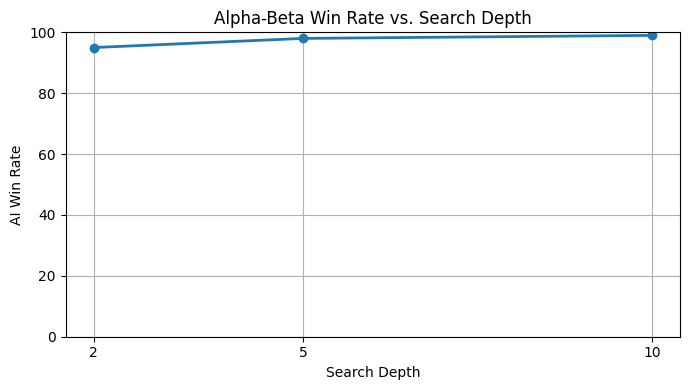

In [28]:
import matplotlib.pyplot as plt

depths = [2, 5, 10]
ab_win_rates = [ab2['p1_wins'], ab5['p1_wins'], ab10['p1_wins']]

plt.figure(figsize=(7, 4))
plt.plot(depths, ab_win_rates, marker='o', linewidth=2)
plt.xlabel('Search Depth')
plt.ylabel('AI Win Rate')
plt.title('Alpha-Beta Win Rate vs. Search Depth')
plt.xticks(depths)
plt.ylim(0, 100)
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
def utility_alt(game):
    own_pits = sum(game.board[game.p1_pits_index[0]: game.p1_pits_index[1] + 1])
    opp_pits = sum(game.board[game.p2_pits_index[0]: game.p2_pits_index[1] + 1])
    # Weighted heuristic: mancala score + 10% weight on pit stone advantage
    return (game.board[game.p1_mancala_index] - game.board[game.p2_mancala_index]
            + 0.1 * (own_pits - opp_pits))

def alphabeta_alt(game, depth, alpha, beta, maximizing, counter=None):
    if counter is not None:
        counter[0] += 1
    done, i = game.winning_eval()
    if done or depth == 0:
        return utility_alt(game), None
    valid_pits = [p for p in range(1, game.pits_per_player + 1) if game.valid_move(p)]
    best_pit = valid_pits[0]
    if maximizing:
        best_score = float('-inf')
        for pit in valid_pits:
            child = copy.deepcopy(game)
            child.play(pit)
            score, i = alphabeta_alt(child, depth - 1, alpha, beta, False, counter)
            if score > best_score:
                best_score, best_pit = score, pit
            alpha = max(alpha, best_score)
            if alpha >= beta:
                break
    else:
        best_score = float('inf')
        for pit in valid_pits:
            child = copy.deepcopy(game)
            child.play(pit)
            score, i = alphabeta_alt(child, depth - 1, alpha, beta, True, counter)
            if score < best_score:
                best_score, best_pit = score, pit
            beta = min(beta, best_score)
            if beta <= alpha:
                break
    return best_score, best_pit

def ab_alt_player(game, depth, maximizing):
    return alphabeta_alt(game, depth, float('-inf'), float('inf'), maximizing)

print("Running Alt Utility AlphaBeta depth=2")
alt2 = run_ai_sim(ab_alt_player, depth=2)
print(f" P1 wins: {alt2['p1_wins']}% | Ties: {alt2['ties']}% | Avg turns: {alt2['avg_turns']} | Avg time/game: {alt2['avg_time_s']}s")

print("\nRunning Alt Utility AlphaBeta depth=5")
alt5 = run_ai_sim(ab_alt_player, depth=5)
print(f" P1 wins: {alt5['p1_wins']}% | Ties: {alt5['ties']}% | Avg turns: {alt5['avg_turns']} | Avg time/game: {alt5['avg_time_s']}s")


Running Alt Utility AlphaBeta depth=2
 P1 wins: 96% | Ties: 1% | Avg turns: 37.3 | Avg time/game: 0.0113s

Running Alt Utility AlphaBeta depth=5
 P1 wins: 100% | Ties: 0% | Avg turns: 31.1 | Avg time/game: 0.2746s


## Alternative Utility Analysis

**Rationale:**  
The standard utility only counts scored stones; the alternative adds `0.1 * (own_pits - opp_pits)` to reward controlling unscored stones as a proxy for future scoring, weighted small enough that pit control never outweighs the actual mancala lead.

- The standard utility function only counted scored stones. The alternative adds `0.1 * (own_pits - opp_pits)` which rewards the unscored stones which are controlling for future scoring. This allows the weighting to be small enoughthat the pit control never outweighs whatever mancala is leading.
- Running this at depth 2 I got 96% on the Alt compared to the 95% on standard
- Running this at depth 5 got it up to 100% compared to the standard 98%
- This means that using the alternative utility function made the standard perform better at both depth levels. Getting to 100% was the signal of better performance.
